In [1]:
import BELA_TESS
import lightkurve as lk

In [2]:
## Information required about target star

# here is an example RGB star from the open cluster NGC 188 (see Howell et al. 2026)
TIC_ID = 461599427
Gaia_ID = 573980327088132608
Gmag = 12.0005
RA = 10.46623296	
Dec = 85.45200205	
pmra = -2.265	
pmdec = -1.204	

# needed for smoothing. Can come from a spectroscopic logg and teff
numax_predicted = 31

In [3]:
## Load TESS Full Frame Images (FFI) using LightKurve

search_result = lk.search_tesscut(f'TIC {TIC_ID}')
search_result.table.sort('year')

sector_list = []
for ii in search_result.mission:
    mm = str(ii).split()[-1]
    sector_list.append(mm)

search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 18,2019,TESScut,1426,TIC 461599427,0.0
1,TESS Sector 19,2019,TESScut,1426,TIC 461599427,0.0
2,TESS Sector 20,2019,TESScut,1426,TIC 461599427,0.0
3,TESS Sector 26,2020,TESScut,1426,TIC 461599427,0.0
4,TESS Sector 25,2020,TESScut,1426,TIC 461599427,0.0
5,TESS Sector 40,2021,TESScut,475,TIC 461599427,0.0
6,TESS Sector 59,2022,TESScut,158,TIC 461599427,0.0
7,TESS Sector 53,2022,TESScut,475,TIC 461599427,0.0
8,TESS Sector 52,2022,TESScut,475,TIC 461599427,0.0


## Create Individual Sector Light Curves

In [4]:
## Focus on one sector FFI at a time. We refer to the cutout of the FFI as a target pixel file (TPF).
tpf_idx = 0

tpf = search_result[tpf_idx].download(cutout_size=15)

The following cell provides an interactive matplotlib widget that you can use to iterate over different aperture mask options. To add an individual pixel to the aperture mask, click on the pixel in the FFI in the left panel. This will automatically update the detrended light curve in the middle panel and the power spectrum in the right panel. When you add another pixel to the aperture mask, the previous light curve and power spectrum will be displayed in red, and the penultimate is shown in blue for comparison. To remove a pixel, click on it again. An example of the usage of this package is provided in the Github README.

The light curve is detrended following the method in Howell et al. 2026.

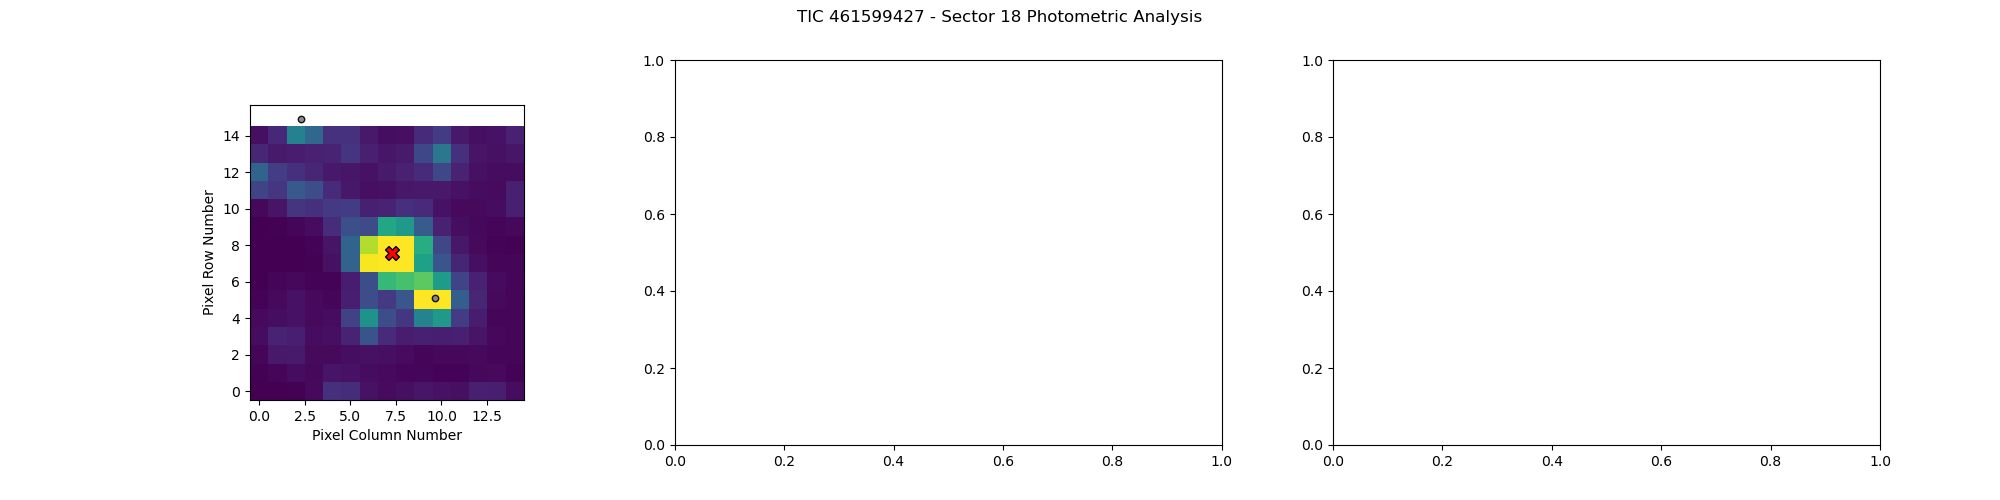

In [11]:
## load in widget to choose aperture mask in TPF (left panel) and see the effects on the light curve (middle panel) and power spectrum (right panel)

# must include this following line for widget to work
%matplotlib widget

selector = BELA_TESS.TPFMaskSelector(TIC_ID, tpf, RA, Dec, pmra, pmdec, Gmag, Gaia_ID, numax_predicted, frame=0)

<Axes: xlabel='Frequency [$\\mathrm{\\mu Hz}$]', ylabel='Power [$\\mathrm{\\frac{ppm^{2}}{\\mu Hz}}$]'>

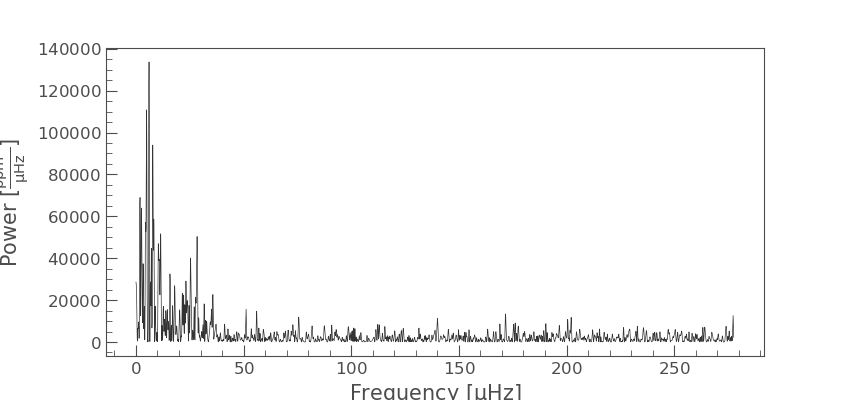

In [6]:
## Run these commands to store the final chosen aperture mask, light curve and power spectrum

ap_mask = selector.get_mask()
lc_sector = selector.update_lightcurve()
psd_sector = selector.update_powerspectra()

# plot final power spectrum
psd_sector.plot()

## from here you can save these products in a format you like

## Select \& Stitch Sector Light Curves to Produce Final Full Light Curve

In [12]:
## Load individual sector light curve. Example files are formated as Sector{sector_number}_LC.txt
import glob
import re

def get_sector_number(f):
    return int(re.search(r'Sector(\d+)', f).group(1))

    
lc_list = []

# lc_files = sorted(glob.glob(f'./LightCurve_files/Gaia{TIC_ID}/Sector*_LC.txt'), key=get_sector_number)
lc_files = sorted(glob.glob(f'./Tutorial_files/TIC{TIC_ID}/Sector*_LC.txt'), key=get_sector_number)

lc_files

['./Tutorial_files/TIC461599427/Sector18_LC.txt',
 './Tutorial_files/TIC461599427/Sector19_LC.txt',
 './Tutorial_files/TIC461599427/Sector20_LC.txt',
 './Tutorial_files/TIC461599427/Sector25_LC.txt',
 './Tutorial_files/TIC461599427/Sector26_LC.txt',
 './Tutorial_files/TIC461599427/Sector40_LC.txt',
 './Tutorial_files/TIC461599427/Sector52_LC.txt',
 './Tutorial_files/TIC461599427/Sector53_LC.txt',
 './Tutorial_files/TIC461599427/Sector59_LC.txt',
 './Tutorial_files/TIC461599427/Sector73_LC.txt',
 './Tutorial_files/TIC461599427/Sector79_LC.txt',
 './Tutorial_files/TIC461599427/Sector86_LC.txt']

There might be some cases, where removing a sector light curve increases the signal-to-noise of the oscillations. The following interactive widget is designed to be able to visually test whether removing certain sectors from the full light curve improves the oscillations in the power spectrum. Similar to the previous widget, click on a light curve to remove. Click on it again to include it back. An example on how to use this widget is provided in the README.

TESS sector start and end times taken from: https://archive.stsci.edu/tess/tess_drn.html

The process of stitching the final full power spectrum together is explained in Howell et al. 2026

new frequency spacing is 0.007814270420642177 muHz. Old frequency spacing was 0.0061822047908778955 muHz


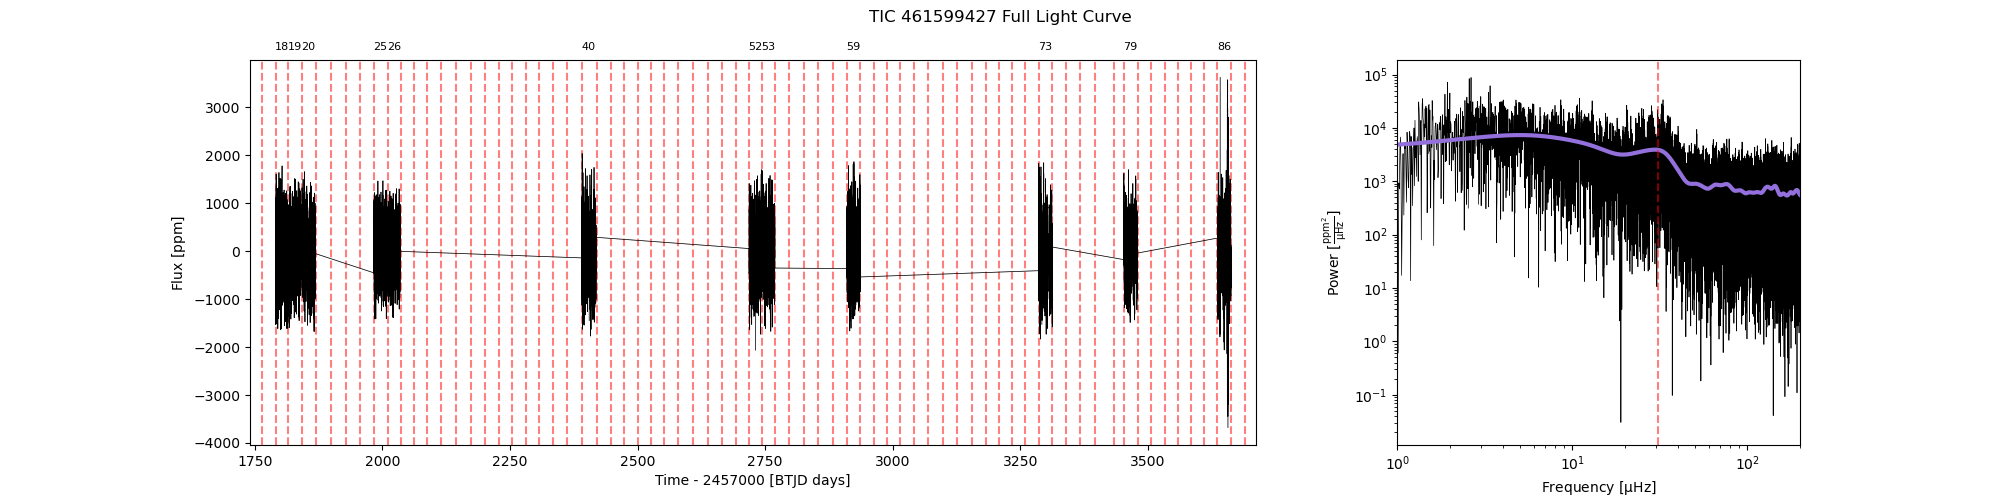

In [13]:
## Widget to test the effect on the final power spectrum when removing certain sector light curves

# must include this following line for widget to work
%matplotlib widget

selector = BELA_TESS.FinalLCSelector(lc_files, numax_predicted, TIC_ID)

new frequency spacing is 0.007814270420642177 muHz. Old frequency spacing was 0.0061822047908778955 muHz


<Axes: xlabel='Frequency [$\\mathrm{\\mu Hz}$]', ylabel='Power [$\\mathrm{\\frac{ppm^{2}}{\\mu Hz}}$]'>

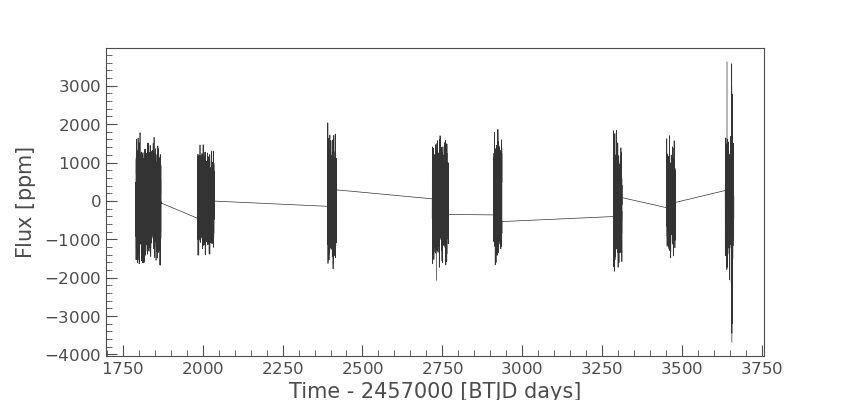

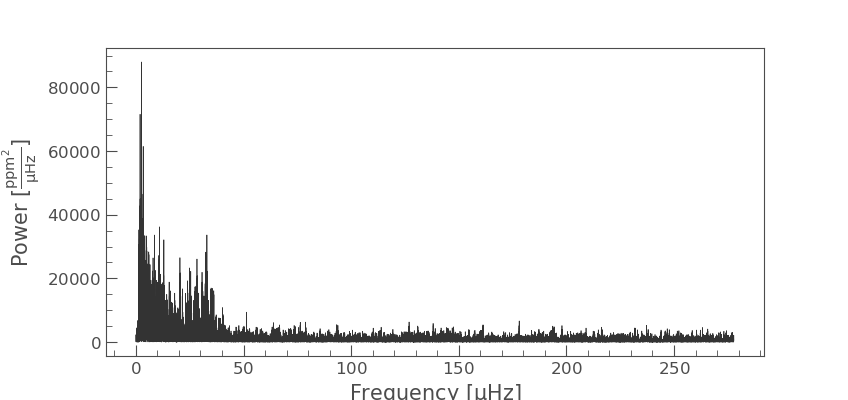

In [14]:
## Run these commands to store and plot the final light curve and power spectrum

lc_all = selector.update_lightcurve()

lc_all.plot()

psd_all = selector.update_powerspectra()

psd_all.plot()

## from here you can save these products in a format you like